In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import shap

In [2]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /Users/aesha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Load and sample data
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
train_df = train_df.sample(frac=0.2, random_state=42)
test_df = test_df.sample(frac=0.2, random_state=42)

In [4]:
# Preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.strip()
    tokens = [word for word in text.split() if word not in stop_words]
    return tokens

train_df['tokens'] = train_df['Tweet'].apply(preprocess_text)
test_df['tokens'] = test_df['Tweet'].apply(preprocess_text)

label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['Sentiment_Label'])
test_df['label'] = label_encoder.transform(test_df['Sentiment_Label'])

In [5]:
# Load GloVe
def load_glove_embeddings(glove_file_path):
    embeddings = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove_path = "glove.6B.50d.txt"
glove_embeddings = load_glove_embeddings(glove_path)

In [6]:
def get_average_embedding(tokens, embeddings, dim=50):
    vectors = [embeddings[token] for token in tokens if token in embeddings]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

X_train = np.vstack(train_df['tokens'].apply(lambda x: get_average_embedding(x, glove_embeddings)))
X_test = np.vstack(test_df['tokens'].apply(lambda x: get_average_embedding(x, glove_embeddings)))
y_train = train_df['label'].values
y_test = test_df['label'].values

In [7]:
# SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [8]:
# PCA for boosting performance
pca = PCA(n_components=30)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Parameters from RandomizedSearchCV: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1.0}
Best Cross-Validation Score from RandomizedSearchCV: 0.5809688405325348
Classification Report for RandomizedSearchCV:
              precision    recall  f1-score   support

           0       0.54      0.68      0.60       420
           1       0.59      0.40      0.47       372
           2       0.60      0.62      0.61       408

    accuracy                           0.57      1200
   macro avg       0.58      0.57      0.56      1200
weighted avg       0.58      0.57      0.57      1200



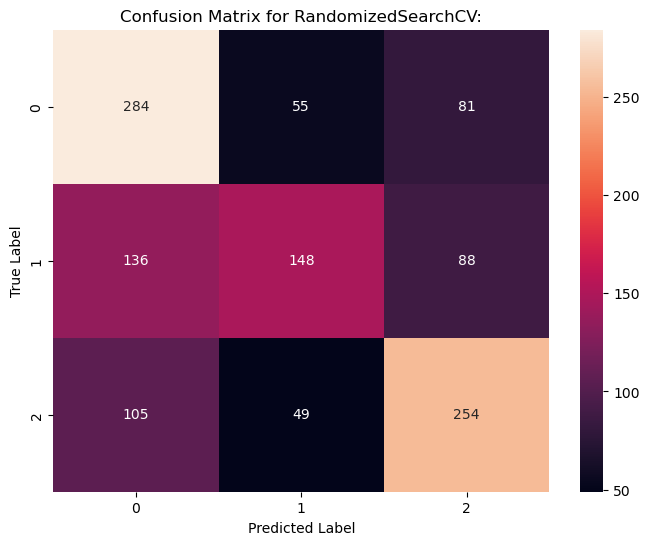

In [9]:
# RandomizedSearchCV
param_dist = {
    'C': np.logspace(-3, 3, 7),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC(probability=True)
random_search = RandomizedSearchCV(estimator=svm_model, param_distributions=param_dist,
                                n_iter=28, cv=5, n_jobs=-1, verbose=1,
                                scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best Cross-Validation Score from RandomizedSearchCV:", random_search.best_score_)

best_svm_model_random = random_search.best_estimator_
y_pred_random = best_svm_model_random.predict(X_test)
y_proba_random = best_svm_model_random.predict_proba(X_test)

print("Classification Report for RandomizedSearchCV:")
print(classification_report(y_test, y_pred_random))

cm = confusion_matrix(y_test, y_pred_random)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for RandomizedSearchCV:")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


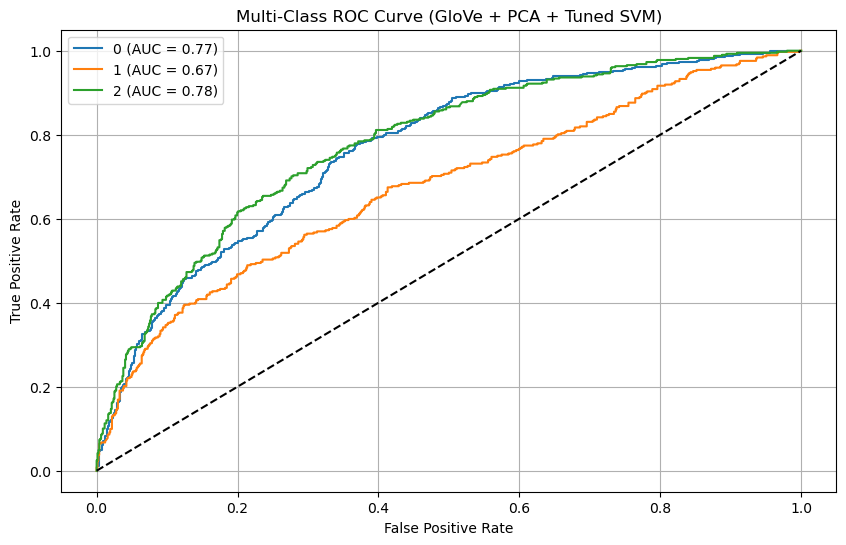

In [12]:
# ROC Curve + AUC
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))

plt.figure(figsize=(10, 6))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_random[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-Class ROC Curve (GloVe + PCA + Tuned SVM)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

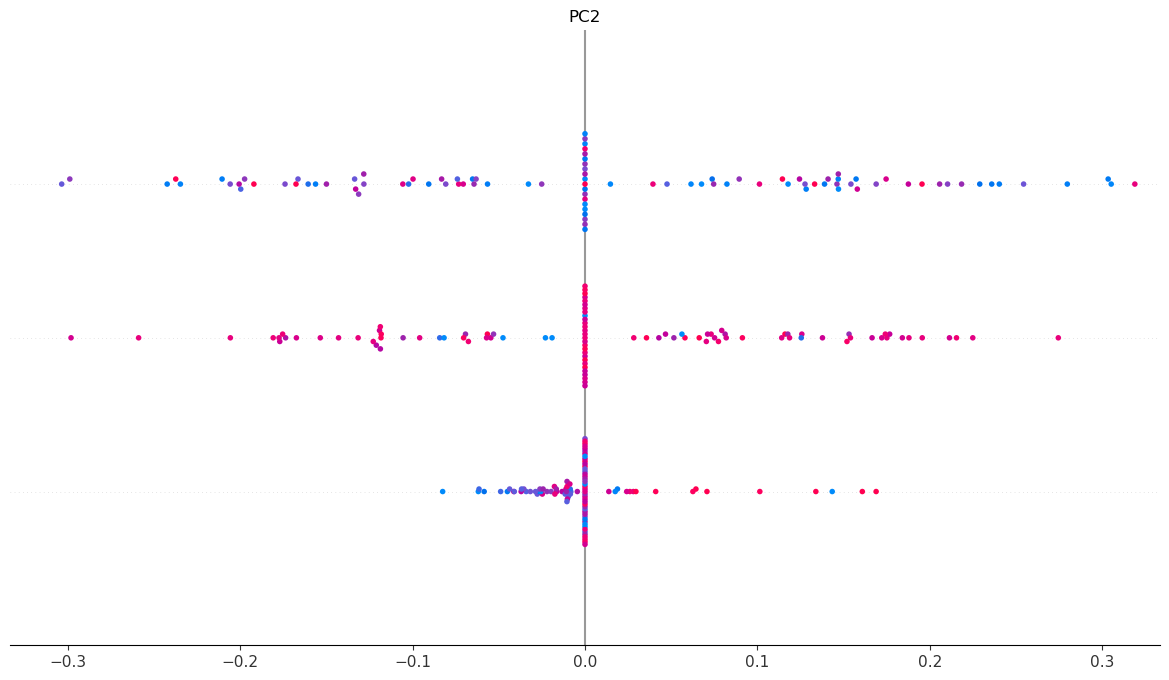

In [14]:
# SHAP Interpretability for SVM (kernel-based) - use KernelExplainer
import shap

# Use a small sample for efficiency
X_shap = X_test[:100]

# SHAP expects a function that outputs probabilities
def predict_fn(X):
    return best_svm_model_random.predict_proba(X)

explainer = shap.KernelExplainer(predict_fn, X_train[:100])
shap_values = explainer.shap_values(X_shap, nsamples=100)

shap.summary_plot(shap_values, X_shap, feature_names=[f"PC{i+1}" for i in range(X_test.shape[1])])

# Used LLM Prompts
1. How to create SVM model using GloVe.
2. Provide code to install for stop words.
3. Perform SVM on the attached training and testing data.
4. How to install GloVe txt file provide step by step guidence.
5. Perform SMOTE, PCA, Model Tuning using RandomizedSearchCV and SHAP interpretability